# Stage 1 — Continuous Flow Matching (unconditional, QM9)

End-to-end smoke run: **train → sample → VUN**. Acceptance = the loop
completes and validity clears a trivial-noise floor. Full validity
(QM9 ~90–100%) needs the full-data, many-epoch run.

## Setup

In [1]:
import os

REPO = "flow-matching-molecules"
if not os.path.isdir(REPO):
    !git clone https://github.com/Nico-Conti/flow-matching-molecules.git
os.chdir(REPO if os.path.basename(os.getcwd()) != REPO else ".")

!pip install -q uv
!uv pip install --system -q -e .   # installs deps + the package from pyproject
import sys; sys.path.insert(0, os.path.abspath("src"))  # flat src/ layout
print("cwd:", os.getcwd())

Cloning into 'flow-matching-molecules'...
remote: Enumerating objects: 93, done.
remote: Counting objects: 100% (93/93), done.
remote: Compressing objects: 100% (73/73), done.
remote: Total 93 (delta 34), reused 77 (delta 18), pack-reused 0 (from 0)
Receiving objects: 100% (93/93), 309.28 KiB | 6.72 MiB/s, done.
Resolving deltas: 100% (34/34), done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.9/24.9 MB 21.3 MB/s eta 0:00:00
cwd: /content/flow-matching-molecules


In [ ]:
import torch
import train, evaluate
print(torch.__version__, "cuda:", torch.cuda.is_available())

## QM9 — Train (subset smoke run)
`subset` caps the corpus for a fast first pass; drop it for the real run.

In [ ]:
(model, history, size_sampler, train_smiles, atom_vocab,
 k_X, k_E, test_smiles) = train.train(
    epochs=50, batch_size=128, subset=None, dataset="qm9")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/1.22k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/5.94M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/132040 [00:00<?, ? examples/s]

epoch 0 step 0 loss 3.7424 loss_x 2.3263 loss_e 1.4161 lr 5.00e-04
epoch 0 step 50 loss 0.6676 loss_x 0.3693 loss_e 0.2983 lr 5.00e-04
epoch 0 step 100 loss 0.5270 loss_x 0.3127 loss_e 0.2143 lr 5.00e-04
epoch 0 step 150 loss 0.4122 loss_x 0.2295 loss_e 0.1827 lr 5.00e-04
epoch 0 step 200 loss 0.3942 loss_x 0.2255 loss_e 0.1686 lr 5.00e-04
epoch 0 step 250 loss 0.4315 loss_x 0.2608 loss_e 0.1707 lr 5.00e-04
epoch 0 step 300 loss 0.3802 loss_x 0.2201 loss_e 0.1601 lr 5.00e-04
epoch 0 step 350 loss 0.3891 loss_x 0.2315 loss_e 0.1575 lr 5.00e-04
epoch 0 step 400 loss 0.3424 loss_x 0.1966 loss_e 0.1458 lr 5.00e-04
epoch 0 step 450 loss 0.4215 loss_x 0.2557 loss_e 0.1657 lr 5.00e-04
epoch 0 step 500 loss 0.3943 loss_x 0.2340 loss_e 0.1603 lr 5.00e-04
epoch 0 step 550 loss 0.3849 loss_x 0.2226 loss_e 0.1623 lr 5.00e-04
epoch 0 step 600 loss 0.3500 loss_x 0.2039 loss_e 0.1461 lr 5.00e-04
epoch 0 step 650 loss 0.3913 loss_x 0.2316 loss_e 0.1597 lr 5.00e-04
epoch 0 step 700 loss 0.3658 loss_x 0

## QM9 — Loss curves


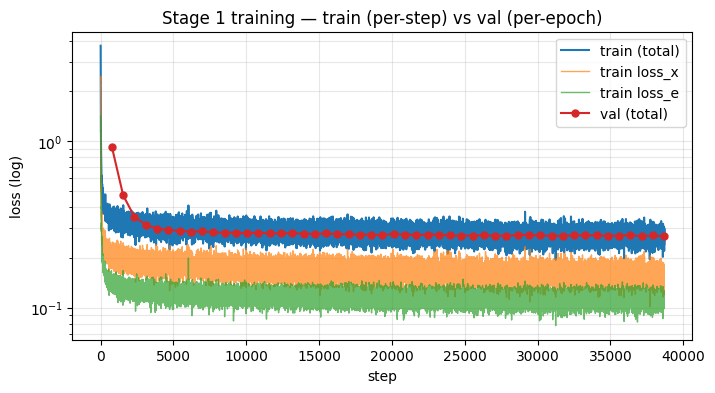

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
plt.semilogy(history["step"], history["loss"],   label="train (total)", lw=1.5)
plt.semilogy(history["step"], history["loss_x"], label="train loss_x", lw=1, alpha=0.7)
plt.semilogy(history["step"], history["loss_e"], label="train loss_e", lw=1, alpha=0.7)
# val_loss is per-epoch; anchor each marker at the last training step of its epoch.
n_epochs = len(history["val_loss"])
if n_epochs > 0:
    steps_per_epoch = max(len(history["step"]) // n_epochs, 1)
    val_x = [(e + 1) * steps_per_epoch - 1 for e in range(n_epochs)]
    plt.semilogy(val_x, history["val_loss"], "o-", label="val (total)", lw=1.5, ms=5)
plt.xlabel("step")
plt.ylabel("loss (log)")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.title("Stage 1 training — train (per-step) vs val (per-epoch)")
plt.show()


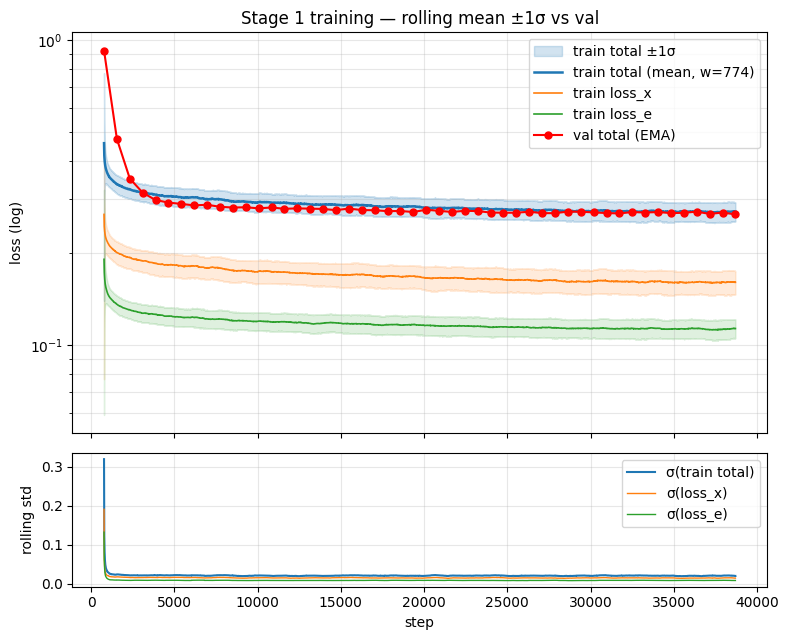

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def rolling_stats(y, w):
    """Right-aligned rolling mean and std over window w. Returns (mean, std),
    both of length len(y)-w+1."""
    y = np.asarray(y, dtype=float)
    mean = np.convolve(y, np.ones(w) / w, mode="valid")
    # Var[X] = E[X^2] - E[X]^2, computed the same windowed way
    mean_sq = np.convolve(y * y, np.ones(w) / w, mode="valid")
    var = np.clip(mean_sq - mean ** 2, 0.0, None)   # clip tiny negatives from FP error
    return mean, np.sqrt(var)

n_epochs = len(history["val_loss"])
steps_per_epoch = max(len(history["step"]) // max(n_epochs, 1), 1)
w = steps_per_epoch                          # 1-epoch smoothing window
steps = np.asarray(history["step"])
x_roll = steps[w - 1:]

mean_tot, std_tot = rolling_stats(history["loss"],   w)
mean_x,   std_x   = rolling_stats(history["loss_x"], w)
x_roll = steps[w - 1:]

mean_tot, std_tot = rolling_stats(history["loss"],   w)
mean_x,   std_x   = rolling_stats(history["loss_x"], w)

mean_tot, std_tot = rolling_stats(history["loss"],   w)
mean_x,   std_x   = rolling_stats(history["loss_x"], w)
mean_e,   std_e   = rolling_stats(history["loss_e"], w)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6.5), sharex=True,
                                gridspec_kw={"height_ratios": [3, 1]})

# --- Top: rolling means with ±1σ bands -------------------------------------
ax1.fill_between(x_roll, np.clip(mean_tot - std_tot, 1e-6, None), mean_tot + std_tot,
                  color="C0", alpha=0.20, label="train total ±1σ")
ax1.fill_between(x_roll, np.clip(mean_x   - std_x,   1e-6, None), mean_x   + std_x,
                  color="C1", alpha=0.15)
ax1.fill_between(x_roll, np.clip(mean_e   - std_e,   1e-6, None), mean_e   + std_e,
                  color="C2", alpha=0.15)

ax1.semilogy(x_roll, mean_tot, color="C0", lw=1.8, label=f"train total (mean, w={w})")
ax1.semilogy(x_roll, mean_x,   color="C1", lw=1.2, label="train loss_x")
ax1.semilogy(x_roll, mean_e,   color="C2", lw=1.2, label="train loss_e")

if n_epochs > 0:
    val_x = [(e + 1) * steps_per_epoch - 1 for e in range(n_epochs)]
    ax1.semilogy(val_x, history["val_loss"], "o-",
                  color="red", lw=1.5, ms=5, label="val total (EMA)")

ax1.set_ylabel("loss (log)")
ax1.set_title("Stage 1 training — rolling mean ±1σ vs val")
ax1.legend(loc="upper right")
ax1.grid(True, which="both", alpha=0.3)

# --- Bottom: rolling std alone, on its own axis ----------------------------
ax2.plot(x_roll, std_tot, color="C0", lw=1.5, label="σ(train total)")
ax2.plot(x_roll, std_x,   color="C1", lw=1.0, label="σ(loss_x)")
ax2.plot(x_roll, std_e,   color="C2", lw=1.0, label="σ(loss_e)")
ax2.set_xlabel("step")
ax2.set_ylabel("rolling std")
ax2.legend(loc="upper right")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
# --- Variance reporting ----------------------------------------------------
def _fmt_row(label, mean, std):
    cv = std / mean if mean > 0 else float("nan")  # coefficient of variation
    print(f"  {label:<22} mean={mean:.4f}  std={std:.4f}  σ/μ={cv:.2%}")

print(f"\nRolling-window stats (w = {w} steps = 1 epoch)")
print("=" * 64)

# Sample at start (first valid window), mid, and end of training
checkpoints = {
    "start (epoch 1)":   0,
    "mid  (epoch N/2)":  len(mean_tot) // 2,
    "end  (epoch N)":    len(mean_tot) - 1,
}
for name, idx in checkpoints.items():
    print(f"\n[{name}]  step {x_roll[idx]}")
    _fmt_row("train total", mean_tot[idx], std_tot[idx])
    _fmt_row("train loss_x", mean_x[idx],   std_x[idx])
    _fmt_row("train loss_e", mean_e[idx],   std_e[idx])

# Final-epoch noise floor (raw, no smoothing — the number to quote)
tail = slice(-w, None)
final_mean = float(np.mean(history["loss"][tail]))
final_std  = float(np.std(history["loss"][tail]))
print(f"\n[final-epoch raw, last {w} steps]")
print(f"  train total            mean={final_mean:.4f}  std={final_std:.4f}  "
      f"σ/μ={final_std/final_mean:.2%}")

# Variance reduction across training
print(f"\nσ(train total) reduction:  {std_tot[0]:.4f} → {std_tot[-1]:.4f}  "
      f"({std_tot[-1]/std_tot[0]:.1%} of initial)")

# val vs train final gap
if n_epochs > 0:
    val_final = float(history["val_loss"][-1])
    print(f"\nFinal val (EMA): {val_final:.4f}   "
          f"Final train mean: {mean_tot[-1]:.4f}   "
          f"gap: {val_final - mean_tot[-1]:+.4f}")



Rolling-window stats (w = 774 steps = 1 epoch)

[start (epoch 1)]  step 773
  train total            mean=0.4586  std=0.3192  σ/μ=69.59%
  train loss_x           mean=0.2678  std=0.1907  σ/μ=71.19%
  train loss_e           mean=0.1908  std=0.1319  σ/μ=69.14%

[mid  (epoch N/2)]  step 19736
  train total            mean=0.2833  std=0.0200  σ/μ=7.07%
  train loss_x           mean=0.1672  std=0.0142  σ/μ=8.52%
  train loss_e           mean=0.1161  std=0.0084  σ/μ=7.21%

[end  (epoch N)]  step 38699
  train total            mean=0.2736  std=0.0195  σ/μ=7.14%
  train loss_x           mean=0.1604  std=0.0140  σ/μ=8.74%
  train loss_e           mean=0.1132  std=0.0080  σ/μ=7.10%

[final-epoch raw, last 774 steps]
  train total            mean=0.2736  std=0.0195  σ/μ=7.14%

σ(train total) reduction:  0.3192 → 0.0195  (6.1% of initial)

Final val (EMA): 0.2679   Final train mean: 0.2736   gap: -0.0056


## QM9 — Evaluate (V/U/N)

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
vun = evaluate.evaluate(model, size_sampler, train_smiles, atom_vocab,
                        k_X, k_E, n_samples=1000, batch=256, steps=100,
                        device=device)
print(vun)

{'validity': 1.0, 'uniqueness': 0.992, 'novelty': 0.6794354838709677, 'n_generated': 1000, 'n_valid': 1000, 'n_unique': 992, 'n_novel': 674, 'repair_rate': 0.137}


## QM9 — Generated molecules (visual sample)


  0: CCC1CC2(CC2C)O1
  1: C1CC2CC3(CO3)C2C1
  2: OCCN1CC1C1CC1
  3: N#CCC1=NCN1C=O
  4: CC1C(C)N2C(C)C12
  5: CC1=NOC(C)N=NO1
  6: COC12CCCC1C2
  7: CCCC(CC)OC=O
  8: CN=CC(C)COC=N
  9: N#CCC=CO
  10: CC(C)=CC(C)C(N)=O
  11: N#CC(=O)N=CC1CC1 (rep)


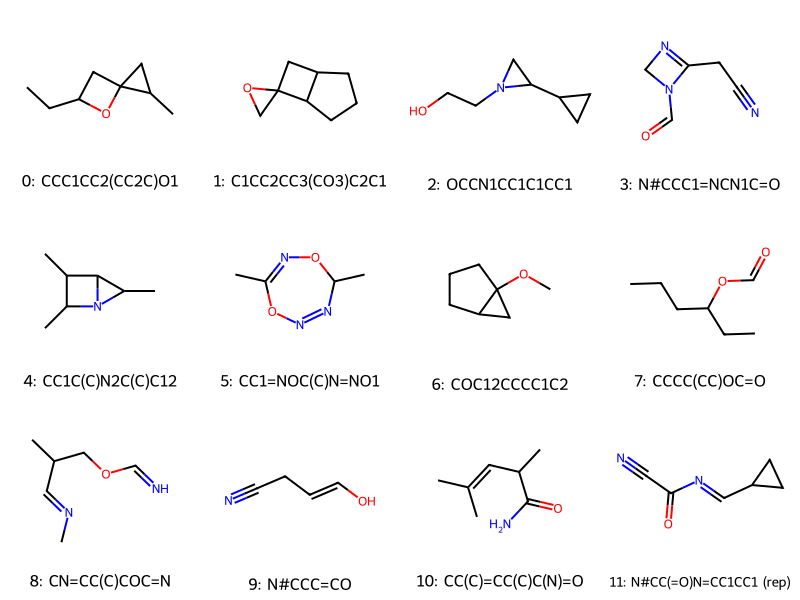

In [ ]:
import torch
from rdkit import Chem
from rdkit.Chem import Draw
from IPython.display import display
from dataset.featurize import tensor_to_mol, largest_fragment
from flow import sample

n_show = 12
n_list = size_sampler.sample(n_show)
with torch.no_grad():
    X_oh, E_oh, mask = sample(model, n_list, k_X, k_E, steps=100, device=device)

mols, legends = [], []
for i in range(n_show):
    n = int(mask[i].sum().item())
    m, was_repaired = tensor_to_mol(X_oh[i, :n].cpu(), E_oh[i, :n, :n].cpu(), atom_vocab)
    m = largest_fragment(m)
    smi = Chem.MolToSmiles(m) if m is not None else "INVALID"
    mols.append(m)
    legends.append(f"{i}: {smi}" + (" (rep)" if was_repaired else ""))
    print(f"  {legends[-1]}")

valid = [(m, l) for m, l in zip(mols, legends) if m is not None]
if valid:
    valid_mols, valid_legends = zip(*valid)
    display(Draw.MolsToGridImage(list(valid_mols), molsPerRow=4, subImgSize=(200, 200),
                                 legends=list(valid_legends)))
else:
    print("No valid mols to render.")


## QM9 — Stage-1 acceptance
Pipeline runs end-to-end and validity beats noise. The strong target (QM9 ~90–100%) is the Phase 1→2 boundary check on a fully trained model.


In [ ]:
assert vun['n_generated'] == 1000
assert vun['validity'] > 0.30, 'validity not above a trivial-noise floor'
print('Stage-1 QM9 pipeline OK:', vun)


## ZINC — Train (subset smoke run)
`subset` caps the corpus for a fast first pass; drop it for the real run.


In [ ]:
(model, history, size_sampler, train_smiles, atom_vocab,
 k_X, k_E, test_smiles) = train.train(
    dataset="zinc", epochs=5, batch_size=128, subset=20000)


## ZINC — Loss curves


In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
plt.semilogy(history["step"], history["loss"],   label="train (total)", lw=1.5)
plt.semilogy(history["step"], history["loss_x"], label="train loss_x", lw=1, alpha=0.7)
plt.semilogy(history["step"], history["loss_e"], label="train loss_e", lw=1, alpha=0.7)
n_epochs = len(history["val_loss"])
if n_epochs > 0:
    steps_per_epoch = max(len(history["step"]) // n_epochs, 1)
    val_x = [(e + 1) * steps_per_epoch - 1 for e in range(n_epochs)]
    plt.semilogy(val_x, history["val_loss"], "o-", label="val (total)", lw=1.5, ms=5)
plt.xlabel("step")
plt.ylabel("loss (log)")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.title("Stage 1 ZINC training — train (per-step) vs val (per-epoch)")
plt.show()


## ZINC — Evaluate (V/U/N)


In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
vun = evaluate.evaluate(model, size_sampler, train_smiles, atom_vocab,
                        k_X, k_E, n_samples=1000, batch=256, steps=100,
                        device=device)
print(vun)


## ZINC — Generated molecules (visual sample)


In [ ]:
import torch
from rdkit import Chem
from rdkit.Chem import Draw
from IPython.display import display
from dataset.featurize import tensor_to_mol, largest_fragment
from flow import sample

n_show = 12
n_list = size_sampler.sample(n_show)
with torch.no_grad():
    X_oh, E_oh, mask = sample(model, n_list, k_X, k_E, steps=100, device=device)

mols, legends = [], []
for i in range(n_show):
    n = int(mask[i].sum().item())
    m, was_repaired = tensor_to_mol(X_oh[i, :n].cpu(), E_oh[i, :n, :n].cpu(), atom_vocab)
    m = largest_fragment(m)
    smi = Chem.MolToSmiles(m) if m is not None else "INVALID"
    mols.append(m)
    legends.append(f"{i}: {smi}" + (" (rep)" if was_repaired else ""))
    print(f"  {legends[-1]}")

valid = [(m, l) for m, l in zip(mols, legends) if m is not None]
if valid:
    valid_mols, valid_legends = zip(*valid)
    display(Draw.MolsToGridImage(list(valid_mols), molsPerRow=4, subImgSize=(200, 200),
                                 legends=list(valid_legends)))
else:
    print("No valid mols to render.")


## ZINC — Stage-1 acceptance
Pipeline runs end-to-end and validity beats noise. The strong target (ZINC ~80–85%) is the Phase 1→2 boundary check on a fully trained model.


In [ ]:
assert vun['n_generated'] == 1000
assert vun['validity'] > 0.30, 'validity not above a trivial-noise floor'
print('Stage-1 ZINC pipeline OK:', vun)
